# **Predicting Cognitive Performance Using Demographic, Health, and Behavioral Factors (NHANES 2013-2014)**

### CS 210: Data Management for Data Science

**Student:** Hemadharshinii Sendhilvel\
**NetID:** hs1244

---

## **Introduction**

Cognitive performance is influenced by a wide range of demographic, biological, and behavioral factors.\
While age is widely recognized as a primary driver of cognitive decline, recent research highlights the importance of modifiable lifestyle factors, such as smoking behavior and physical activity. 

Understanding these relationships is important for identifying potential interventions that may delay or mitigate cognitive decline.

In this notebook, we analyze data from the National Health and Nutrition Examination Survey (NHANES) 2013-2014 cycle to build predictive models of cognitive performance using:
- Demographic variables
- Physical health indicators
- Behavioral factors
  
Cognitive performance is measured using the Digit Symbol Substitution Test (DSST), a widely used neuropsychological assessment.

### **Research Question**
> To what extent can cognitive performance be predicted using demographic, health, and behavioral variables?

In the notebook, we:
- Integrate multiple datasets,
- Perform data cleaning and feature engineering,
- Use SQL for structured data merging,
- Apply machine learning models, and
- Interpret predictive performance and feature importance.

---

## **Imports & Setups**

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# database 
import sqlite3

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error

# style
sns.set(style = "whitegrid")

# database connection
conn = sqlite3.connect("nhanes.db")

---

## **Data Sources**

We use multiple publicly available datasets from the NHANES 2013-2014 cycle:

### 1. Demographic Data (`DEMO_H`)
- Age, gender, and education level
- Provides foundational participant characteristics

### 2. Cognitive Functioning (`CFQ_H`)
- Digit Symbol Substitution Test (DSST) scores
- Measures processing speed and cognitive performance (our target variable)

### 3. Body Measures (`BMX_H`)
- Height and weight data
- Used to compute Body Mass Index (BMI)

### 4. Smoking - Cigarette Use (`SMQ_H`)
- Smoking history
- Behavioral risk factor (modifiable to an extent)

### 5. Physical Activity (`PAQ_H`)
- Activity participation
- Lifestyle variable (modifiable to an extent)

These datasets are merged using a unique participant identifier (`SEQN`).

---

## **Data Loading & Cleaning**

### **Demographic Data (`DEMO_H`)**

This dataset contains participant-level demographic information. 

We focus on: 
- Age: Strong predictor of cognition
- Gender: Demographic control variable
- Education: Important factor influencing cognition (key socioeconomic factor)

These variables will later be used as features in our predictive model. 

In [2]:
# load & assess dataset
demo = pd.read_sas("../data/raw/nhanes/DEMO_H.xpt")
display(demo.head())

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557.0,8.0,2.0,1.0,69.0,NaN,4.0,4.0,1.0,NaN,...,3.0,4.0,NaN,13281.237386,13481.042095,1.0,112.0,4.0,4.0,0.84
1,73558.0,8.0,2.0,1.0,54.0,NaN,3.0,3.0,1.0,NaN,...,3.0,1.0,1.0,23682.057386,24471.769625,1.0,108.0,7.0,7.0,1.78
2,73559.0,8.0,2.0,1.0,72.0,NaN,3.0,3.0,2.0,NaN,...,4.0,1.0,3.0,57214.803319,57193.285376,1.0,109.0,10.0,10.0,4.51
3,73560.0,8.0,2.0,1.0,9.0,NaN,3.0,3.0,1.0,119.0,...,3.0,1.0,4.0,55201.178592,55766.512438,2.0,109.0,9.0,9.0,2.52
4,73561.0,8.0,2.0,2.0,73.0,NaN,3.0,3.0,1.0,NaN,...,5.0,1.0,5.0,63709.667069,65541.871229,2.0,116.0,15.0,15.0,5.00


In [3]:
# clean demographics data
# =======================

# will keep only the variables that are useful for modeling cognitive performance: 
# - SEQN: unique participant ID (will use to merge datasets) 
# - RIDAGEYR: age in years (strong predictor of cognition) from ages 1 to 79 years of age
# - RIAGENDR: gender (demographic control variable) (1 - male, 2 - female)
# - DMDHREDU: education (important predictor of cognitive ability)

demo = demo[["SEQN", "RIDAGEYR", "RIAGENDR", "DMDHREDU"]]

# rename columns for clarity, as NHANES variable names are cryptic

demo = demo.rename(columns={
    "SEQN": "id",
    "RIDAGEYR": "age",
    "RIAGENDR": "gender",
    "DMDHREDU": "education"
})

# clean categorical variables

# gender: convert numerical codes to readable labels
demo["gender"] = demo["gender"].map({
    1: "male",
    2: "female"
})

# education: keep only valid, meaningful categories
# we exclude "refused" and "don't know" because they do not represent
# actual educational attainment and would distort analysis
# (education can be a strong confounder in cognitive studies)

# keep only valid responses (1-5 represent real education levels)
demo = demo[demo["education"].isin([1, 2, 3, 4, 5])]

# map to readable labels after filtering
demo["education"] = demo["education"].map({
    1: "<9th grade",
    2: "9-11th grade",
    3: "high school/ged",
    4: "some college",
    5: "college graduate",
})

# handle missing values
# drop rows missing critical variables (age, gender)
# education can be missing but is still useful when present

demo = demo.dropna(subset = ["age", "gender"])

# final check
print("Cleaned Demographic Data:\n")
display(demo.head())

Cleaned Demographic Data:



,id,age,gender,education
0,73557.0,69.0,male,high school/ged
1,73558.0,54.0,male,high school/ged
2,73559.0,72.0,male,some college
3,73560.0,9.0,male,high school/ged
4,73561.0,73.0,female,college graduate


#### **Note on Age Variable (NHANES Limitation)** 

The age variable (RIDAGEYR) reports exact age for participants aged 1-79.\
All participants aged 80 and above are coded as "80" to protect confidentiality, meaning exact ages for older adults are not available.\
This introduces a form of top-coding, which slightly reduces variability in older age groups and should be considered when interpreting age-related trends in cognitive performance.

### **Cognitive Functioning (`CFQ_H`)**

This dataset contains cognitive test results.

We use the **Digit Symbol Substitution Test (DSST)** as our measure for cognitive performance:
- A widely used measure of cognitive performance
- Captures processing speed, attention, and working memory
- Scores range from 0-105 (higher = better performance)

**Note** This test is administered only to participants aged 60+, which will influence our final merged dataset

In [4]:
# load & assess dataset
cfq = pd.read_sas("../data/raw/nhanes/CFQ_H.xpt")
display(cfq.head())

,SEQN,CFASTAT,CFALANG,CFDCCS,CFDCRNC,CFDCST1,CFDCST2,CFDCST3,CFDCSR,CFDCIT1,CFDCIT2,CFDCIT3,CFDCIR,CFDAPP,CFDARNC,CFDAST,CFDDPP,CFDDRNC,CFDDS
0,73557.0,1.0,1.0,1.0,NaN,4.0,7.0,9.0,7.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,16.0,1.0,NaN,54.0
1,73559.0,1.0,1.0,1.0,NaN,4.0,8.0,7.0,6.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,13.0,1.0,NaN,63.0
2,73561.0,1.0,1.0,1.0,NaN,6.0,10.0,10.0,10.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,19.0,1.0,NaN,59.0
3,73564.0,1.0,1.0,1.0,NaN,5.0,6.0,6.0,7.0,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,1.0,NaN,20.0,1.0,NaN,79.0
4,73567.0,1.0,1.0,1.0,NaN,6.0,9.0,10.0,10.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,15.0,1.0,NaN,30.0


In [5]:
# clean cognitive data
# =======================

# select dsst column
# CFDDS = digital symbol substitution test score
# this is a standardized cognitive performance measure
# range: 0-105 (higher = better cognitive performance)
# will also keep SEQN (participant IDs) for merging

cfq = cfq[["SEQN", "CFDDS"]]

# rename columns for clarity

cfq = cfq.rename(columns = {
    "SEQN": "id",
    "CFDDS": "dsst_score"
})

# handle missing values (drop rows with no score)
cfq = cfq.dropna(subset = ["dsst_score"])

# ensure valid score range
# keep only valid DSST scores (0-105)
cfq = cfq[(cfq["dsst_score"] >= 0) & (cfq["dsst_score"] <= 105)]

# final check
print("Cleaned Cognitive Data (DSST):\n")
display(cfq.head())

Cleaned Cognitive Data (DSST):



,id,dsst_score
0,73557.0,54.0
1,73559.0,63.0
2,73561.0,59.0
3,73564.0,79.0
4,73567.0,30.0


### **Body Measures (`BMX_H`)**

This dataset provides physical health measurements. 

We use:
- Height and weight to compute Body Mass Index (BMI)
- BMI = weight (kg) / height (m) ^ 2

BMI serves as a general indicator of health status.

In [6]:
# load & assess dataset
bmx = pd.read_sas("../data/raw/nhanes/BMX_H.xpt")
display(bmx.head())

,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM
0,73557.0,1.0,78.3,NaN,NaN,NaN,NaN,NaN,171.3,NaN,...,35.3,NaN,100.0,NaN,20.5,20.6,NaN,NaN,20.6,NaN
1,73558.0,1.0,89.5,NaN,NaN,NaN,NaN,NaN,176.8,NaN,...,34.7,NaN,107.6,NaN,24.2,24.5,NaN,NaN,24.4,NaN
2,73559.0,1.0,88.9,NaN,NaN,NaN,NaN,NaN,175.3,NaN,...,33.5,NaN,109.2,NaN,25.8,25.4,NaN,NaN,25.6,NaN
3,73560.0,1.0,32.2,NaN,NaN,NaN,NaN,NaN,137.3,NaN,...,21.0,NaN,61.0,NaN,14.8,15.0,NaN,NaN,14.9,NaN
4,73561.0,3.0,52.0,NaN,NaN,NaN,NaN,NaN,162.4,NaN,...,25.2,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0


In [7]:
# clean body measures data
# =======================

# keep relevant columns: weight (BMXWT) & height (BMXHT)
# will use to compute BMI, which is a useful health indicator
# will also keep SEQN (participant IDs) for merging

bmx = bmx[["SEQN", "BMXWT", "BMXHT"]]

# rename columns for clarity

bmx = bmx.rename(columns = {
    "SEQN": "id",
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm"
})

# handle missing values
bmx = bmx.dropna(subset = ["weight_kg", "height_cm"])

# compute BMI
# BMI = weight (kg) / height (m)^2
bmx["bmi"] = bmx["weight_kg"] / ((bmx["height_cm"] / 100) ** 2)

# final check
print("Cleaned Body Measures Data:\n")
display(bmx.head())

Cleaned Body Measures Data:



,id,weight_kg,height_cm,bmi
0,73557.0,78.3,171.3,26.683761
1,73558.0,89.5,176.8,28.632450
2,73559.0,88.9,175.3,28.929300
3,73560.0,32.2,137.3,17.081059
4,73561.0,52.0,162.4,19.716567


### **Smoking - Cigarette Use (`SMQ_H`)**

This dataset captures smoking history. 

We use:
- SMQ020, which indicates if a person has smoked at least 100 cigarettes in their lifetime

This measure is a commonly used threshold to classify lifetime smokers.

In [8]:
# load & assess dataset
smq = pd.read_sas("../data/raw/nhanes/SMQ_H.xpt")
display(smq.head())

,SEQN,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMQ078,SMD641,...,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ670,SMQ848,SMQ852Q,SMQ852U,SMAQUEX2
0,73557.0,1.0,1.700000e+01,3.0,3.0,4.0,66.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,73558.0,1.0,5.397605e-79,2.0,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0
2,73559.0,1.0,2.000000e+01,3.0,40.0,4.0,26.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,73561.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,73562.0,1.0,1.800000e+01,3.0,16.0,4.0,40.0,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [9]:
# clean smoking dataset
# =======================

# keep relevant columns:
# will keep SMQ020 = smoked at least 100 cigarettes in life (1 = yes, 2 = no)
# will also keep SEQN (participant IDs) for merging

smq = smq[["SEQN", "SMQ020"]]

# rename columns for clarity

smq = smq.rename(columns = {
    "SEQN": "id",
    "SMQ020": "smoking_status"
})

# map values to readable categories

smq["smoking_status"] = smq["smoking_status"].map({
    1: "smoker",
    2: "non-smoker"
})

# handle missing values
smq = smq.dropna(subset = ["smoking_status"])

# final check
print("Cleaned Smoking Data:\n")
display(smq.head())

Cleaned Smoking Data:



,id,smoking_status
0,73557.0,smoker
1,73558.0,smoker
2,73559.0,smoker
3,73561.0,non-smoker
4,73562.0,smoker


### **Physical Activity (`PAQ_H`)**

This dataset captures engagement in physical activity.

We use:
- PAQ605, which indicates a person's participation in moderate recreational activity

This variable helps approximate general activity level. 

In [10]:
# load & assess dataset
paq = pd.read_sas("../data/raw/nhanes/PAQ_H.xpt")
display(paq.head())

,SEQN,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,...,PAQ762,PAQ764,PAQ766,PAQ679,PAQ750,PAQ770,PAQ772A,PAQ772B,PAQ772C,PAAQUEX
0,73557.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,73558.0,2.0,NaN,NaN,1.0,1.0,10.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,73559.0,2.0,NaN,NaN,1.0,7.0,30.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,73560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,5.0,4.0,NaN,1.0,2.0,NaN,NaN,NaN,1.0
4,73561.0,2.0,NaN,NaN,1.0,2.0,30.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [11]:
# clean physical activity data
# =======================

# keep relevant columns:
# will keep PAQ605 = moderate recreational activity (1 = yes, 2 = no)
# will also keep SEQN (participant IDs) for merging

paq = paq[["SEQN", "PAQ605"]]

# rename columns for clarity

paq = paq.rename(columns = {
    "SEQN": "id",
    "PAQ605": "phys_activity"
})

# map values

paq["phys_activity"] = paq["phys_activity"].map({
    1: "active",
    2: "inactive"
})

# handle missing values
paq = paq.dropna(subset = ["phys_activity"])

# final check
print("Cleaned Physical Activity Data:\n")
display(paq.head())

Cleaned Physical Activity Data:



,id,phys_activity
0,73557.0,inactive
1,73558.0,inactive
2,73559.0,inactive
4,73561.0,inactive
5,73562.0,active


---

## **Data Integration Using SQL**

In [12]:
# load all datasets into SQL

demo.to_sql("demo", conn, if_exists = "replace", index = False)
cfq.to_sql("cfq", conn, if_exists = "replace", index = False)
bmx.to_sql("bmx", conn, if_exists = "replace", index = False)
smq.to_sql("smq", conn, if_exists = "replace", index = False)
paq.to_sql("paq", conn, if_exists = "replace", index = False)

7147

In [13]:
# merge datasets (using SQL join)

# SQL query
query = """
SELECT
    demo.id,
    demo.age,
    demo.gender,
    demo.education,
    cfq.dsst_score,
    bmx.bmi,
    smq.smoking_status,
    paq.phys_activity
FROM demo
INNER JOIN cfq ON demo.id = cfq.id
INNER JOIN bmx ON demo.id = bmx.id
INNER JOIN smq ON demo.id = smq.id
INNER JOIN paq ON demo.id = paq.id
"""
# use inner join to ensure all entries have all features & target

df = pd.read_sql_query(query, conn)

# check merged dataset
print("Merged Dataset:")
display(df.head())

Merged Dataset:


,id,age,gender,education,dsst_score,bmi,smoking_status,phys_activity
0,73557.0,69.0,male,high school/ged,54.0,26.683761,smoker,inactive
1,73559.0,72.0,male,some college,63.0,28.929300,smoker,inactive
2,73561.0,73.0,female,college graduate,59.0,19.716567,non-smoker,inactive
3,73564.0,61.0,female,college graduate,79.0,35.677124,non-smoker,inactive
4,73567.0,65.0,male,9-11th grade,30.0,21.970435,smoker,active


---

## **Exploratory Data Analysis**

Before building predictive models, we explore the dataset to:
- Understand variable distributions,
- Identify potential relationships with cognitive performance
- Detect missing data or anomalies
- Inform feature selection and modeling choices

This analysis is critical because it helps ensure that modeling decisions are data-driven rather than arbitrary.

### **Dataset Overview**

In [14]:
# basic dataset info

print("Dataset Shape:", df.shape)
print("\nColumn Types:\n")
print(df.dtypes)

print("\nSummary Statistics:\n")
display(df.describe())

Dataset Shape: (1545, 8)

Column Types:

id                float64
age               float64
gender             object
education          object
dsst_score        float64
bmi               float64
smoking_status     object
phys_activity      object
dtype: object

Summary Statistics:



,id,age,dsst_score,bmi
count,1545.000000,1545.000000,1.545000e+03,1545.000000
mean,78630.734628,69.569579,4.610485e+01,29.059206
std,2968.669910,6.707372,1.717502e+01,6.308685
min,73557.000000,60.000000,5.397605e-79,14.186790
25%,76091.000000,64.000000,3.400000e+01,24.776906
50%,78598.000000,69.000000,4.600000e+01,28.013427
75%,81262.000000,75.000000,5.800000e+01,32.184250
max,83724.000000,80.000000,1.050000e+02,63.044611


### **Target Variable: DSST Score**

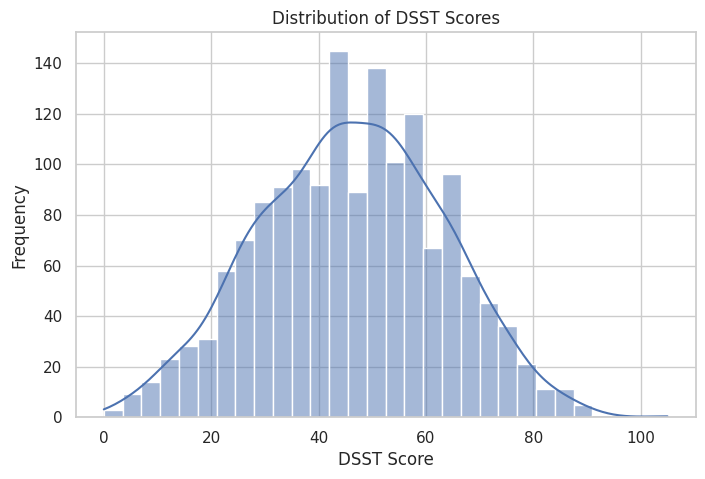

In [15]:
# target variable distribution
# =======================

plt.figure(figsize = (8, 5))
sns.histplot(df["dsst_score"], bins = 30, kde = True)

plt.title("Distribution of DSST Scores")
plt.xlabel("DSST Score")
plt.ylabel("Frequency")
plt.show()

### **Age vs Cognitive Performance**

In [ ]:
# age versus dsst
# =======================

plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "age", y = "dsst_score", alpha = 0.6)

sns.regplot(data = df, x = "age", y = "dsst_score",
            scatter = False, color = "red")

plt.title("Age vs Cognitive Performance")
plt.xlabel("Age")
plt.ylabel("DSST Score")
plt.show()

### **Gender vs Cognitive Performance**

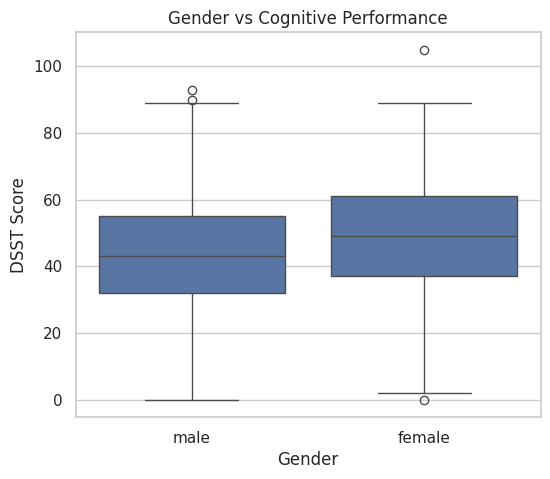

In [17]:
# gender versus dsst
# =======================

plt.figure(figsize = (6, 5))
sns.boxplot(data = df, x = "gender", y = "dsst_score")

plt.title("Gender vs Cognitive Performance")
plt.xlabel("Gender")
plt.ylabel("DSST Score")

plt.show()

### **Education vs Cognitive Performance**

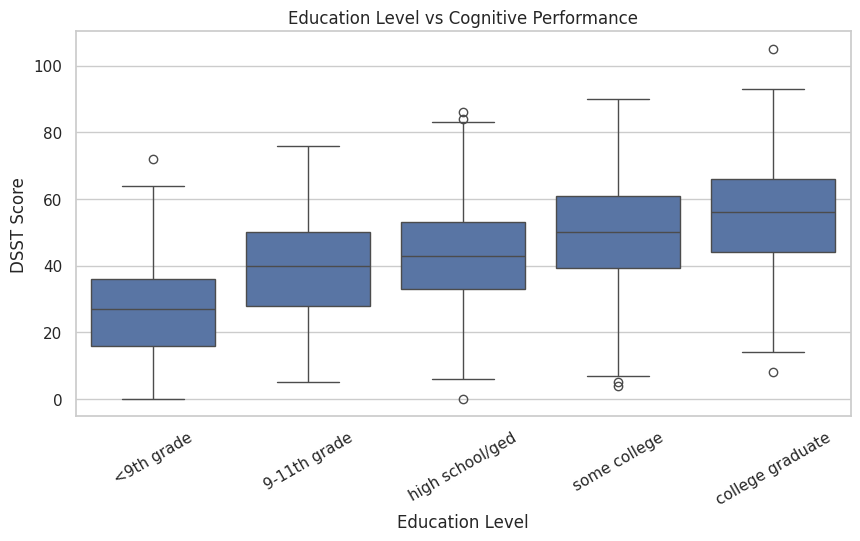

In [18]:
# education versus dsst
# =======================

# clean & order education
# define correct order (least to most education)
edu_order = [
    "<9th grade",
    "9-11th grade",
    "high school/ged",
    "some college",
    "college graduate"
]

# filter out unwanted categories
edu_clean = df[df["education"].isin(edu_order)].copy()

# convert to ordered categorical
edu_clean["education"] = pd.Categorical(
    edu_clean["education"],
    categories = edu_order,
    ordered = True
)

# plot figure
plt.figure(figsize = (10, 5))
sns.boxplot(data = edu_clean, x = "education", y = "dsst_score")

plt.xticks(rotation=30)
plt.title("Education Level vs Cognitive Performance")
plt.xlabel("Education Level")
plt.ylabel("DSST Score")
plt.show()

### **BMI vs Cognitive Performance**

In [ ]:
# bmi versus dsst
# =======================

plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "bmi", y = "dsst_score", alpha = 0.6)

sns.regplot(data = df, x = "bmi", y = "dsst_score",
            scatter = False, color = "red")

plt.title("BMI vs Cognitive Performance")
plt.xlabel("BMI")
plt.ylabel("DSST Score")
plt.show()

### **Smoking Status vs Cognitive Performance**

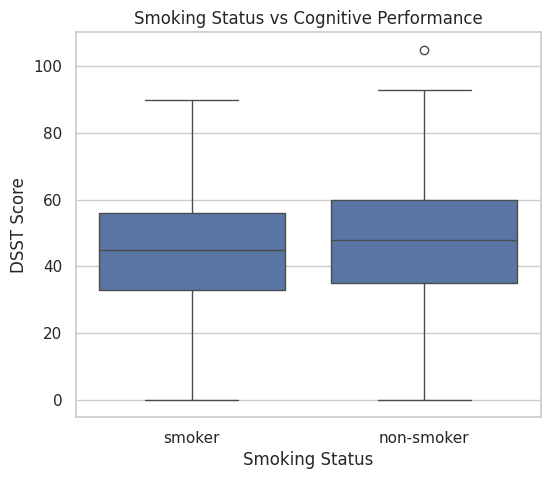

In [20]:
# smoking versus dsst
# =======================

plt.figure(figsize = (6, 5))
sns.boxplot(data = df, x = "smoking_status", y = "dsst_score")

plt.title("Smoking Status vs Cognitive Performance")
plt.xlabel("Smoking Status")
plt.ylabel("DSST Score")
plt.show()

### **Physical Activity vs Cognitive Performance**

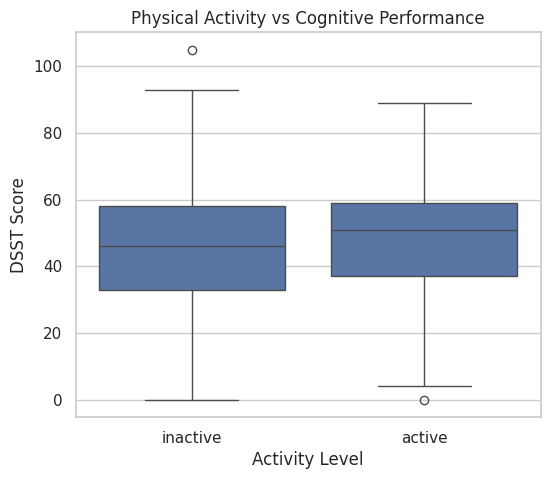

In [21]:
# physical activity versus dsst
# =======================

plt.figure(figsize = (6, 5))
sns.boxplot(data = df, x = "phys_activity", y = "dsst_score")

plt.title("Physical Activity vs Cognitive Performance")
plt.xlabel("Activity Level")
plt.ylabel("DSST Score")
plt.show()

### **Correlation Analysis**

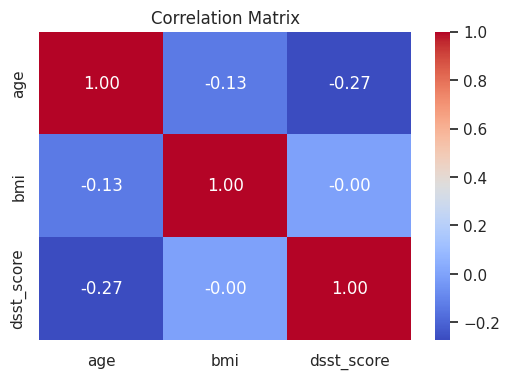

In [22]:
# correlation matrix
# =======================

# select numeric variables
numeric_df = df[["age", "bmi", "dsst_score"]]

corr = numeric_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## **Interpretation of Visualizations**

### **DSST Distribution**
The DSST scores appear approximately normally distributed, with minor irregularities in the middle range.\
Overall, the target variable is well-suited for regression modeling.

### **Age vs Cognitive Performance**
There is a clear negative relationship between age and DSST score, indicating declining cognitive performance with age.\
However, the wide spread of scores at each age suggests age alone is not sufficient to explain variability.\
The top-coding of age at 80 may also slightly compress trends among older participants.

### **Gender vs Cognitive Performance**
Females show a slightly higher median DSST score than males, but the difference is small, suggesting gender is not a strong predictor.

### **Education Level vs Cognitive Performance**
A strong positive relationship is observed.\
Higher levels of education are associated with higher DSST scores, making education one of the most influential predictors.

### **BMI vs Cognitive Performance**
There is little to no clear relationship between BMI and DSST score.\
Any trend is weak, indicating BMI is not a strong predictor on its own.

### **Smoking vs Cognitive Performance**
Non-smokers show slightly higher median scores and greater variability, but overall differences are minimal.

### **Physical Activity vs Cognitive Performance**
Active individuals have a slightly higher median DSST score and a tighter distribution, suggesting a modest positive association with cognitive performance.

### **Correlation Summary**
- Age: -0.28 (moderate negative relationship)
- BMI: ~0.00 (no meaningful relationship)

Overall, age and education stand out as the strongest predictors, while BMI, smoking, and physical activity show weaker associations.

---

## **Modeling Cognitive Performance**

In this section, we finally build machine learning models to predict cognitive performance (DSST score) using demographic, health, and behavioral features. 

We compare multiple models to evaluate:
- Predictive performance
- Ability to capture non-linear relationships
- Sensitivity to different feature types

---

### **Feature Selection**

We include the follow predictors:
- Age (continuous)
- Gender (categorical)
- Education (categorical)
- BMI (continuous)
- Smoking Status (categorical)
- Physical Activity (categorical)

The target variable is:
- DSST Score


### **Train-Test Split**
We split the dataset into training and testing sets to evaluate model generalization.

In [23]:
# define features and target
# =======================
X = df[["age", "gender", "education", "bmi", "smoking_status", "phys_activity"]]
y = df["dsst_score"]

# train-test split
# =======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

# check split
print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training Set Size: (1236, 6)
Testing Set Size: (309, 6)


### **Preprocessing Pipeline**

We handle:
- Categorical variables = one-hot encoding
- Numerical variables = passed through unchanged

In [24]:
# preprocessing
# =======================

categorical_features = ["gender", "education", "smoking_status", "phys_activity"]
numerical_features = ["age", "bmi"]

preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown = "ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

### **Model 1: Linear Regression**

A baseline model that assumes a linear relationship between predictors and DSST score.

In [25]:
# linear regression model
# =======================

lr_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# train model
lr_pipeline.fit(X_train, y_train)

# predictions
y_pred_lr = lr_pipeline.predict(X_test)

# evaluation
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Performance:\n")
print("R^2:", r2_lr)
print("RMSE:", rmse_lr)

Linear Regression Performance:

R^2: 0.3946483192935659
RMSE: 13.359188918363074


### **Model 2: Decision Tree**

Captures non-linear relationships and interactions between variables.

In [26]:
# decision tree model
# =======================

dt_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth = 5, random_state = 42))
])

# train model
dt_pipeline.fit(X_train, y_train)

# predictions
y_pred_dt = dt_pipeline.predict(X_test)

# evaluation
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree Performance:\n")
print("R^2:", r2_dt)
print("RMSE:", rmse_dt)

Decision Tree Performance:

R^2: 0.3374134792940524
RMSE: 13.976470541514287


### **Model 3: Random Forest**

An ensemble method that improves performance by averaging multiple decision trees.

In [27]:
# random forest model
# =======================

rf_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators = 100,
        max_depth = 7,
        random_state = 42
    ))
])

# train
rf_pipeline.fit(X_train, y_train)

# predict
y_pred_rf = rf_pipeline.predict(X_test)

# evaluate
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance:\n")
print("R^2:", r2_rf)
print("RMSE:", rmse_rf)

Random Forest Performance:

R^2: 0.33727421514273936
RMSE: 13.977939269734883


### **Model Comparison**

In [28]:
# compare models
# =======================

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R^2": [r2_lr, r2_dt, r2_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf]
})

display(results)

,Model,R^2,RMSE
0,Linear Regression,0.394648,13.359189
1,Decision Tree,0.337413,13.976471
2,Random Forest,0.337274,13.977939


### **Interpretation of Results**

The Linear Regression model achieved the best performance (R^2 = 0.395, lowest RMSE), outperforming both tree-based models.\
This suggests that the relationships between predictors and DSST scores are largely linear and that added model complexity did not improve predictive power.

Both the Decision Tree and Random Forest models performed worse and had nearly identical results, indicating that they may not be capturing additional meaningful structure in the data. This could be due to:
- Limited feature set
- Weak non-linear relationships
- Insufficient tuning of model hyperparameters

Overall, these results suggest that simpler models are sufficient for this task, and that demographic variables like age and education likely drive most of the predictive signal.

---

## **Conclusion**

This analysis examined the extent to which cognitive performance (measured by DSST score) can be predicted using demographic, health, and behavioral variables from NHANES 2013-2014 data. 

Overall, the models achieved moderate predictive performance, with the Linear Regression model performing best (R^2 = 0.39).\
This suggests that while the selected variables explain some variation in cognitive performance, a substantial portion remains unaccounted for. 

Among the predictors:
- Age showed the strongest negative relationship with cognitive performance
- Education emerged as a key positive predictor
- BMI, smoking status, and physical activity had relatively weak associations

These findings indicate that demographic factors, particularly age and education, play a larger role than the behavioral data and health variables included in this analysis. 

### **Limitations**

Several limitations should be considered:
- The merged dataset includes only participants aged 60+, limiting generalizability
- Age is top-coded at 80, reducing variability among older individuals
- Behavioral variables (smoking, physical activity) are simplified and may not capture intensity or duration
- The feature set is limited; important predictors such as income, diet, or medical conditions were not included
- No hyperparameter tuning was performed for tree-based models

### **Future Work**

Future improvements could include:
- Incorporating additional NHANES variables (e.g., income, chronic conditions)
- Applying feature engineering or interaction terms
- Performing hyperparameter tuning for tree-based models
- Testing more advanced models (e.g., gradient boosting)

---